In [1]:
import mlflow
import pandas as pd
mlflow.set_tracking_uri("../mlruns")
experiment_id = "914879025403898454"
client = mlflow.tracking.MlflowClient()


In [2]:
# runs = ["288611b410b24effb259a5255f40ded4","1bdd141dedae49158453f21484f68893","45f1860155cb47d7a9f443b5a19d3a2b","311531096c934996a31462b03f083d05","408c64837abe437fbb07e4ed29646b0b"]
runs=["894c779caea64dee8d15fa02368865c9","68764b0737eb4b37b68ab8964623189c","f96ccc0ec05e436e89ef17f18f4ca21f","c86a246338604a35ad7e31a7cbe60fd2","bc257b456580460f9ef304f36f8f8a40","98d5e35107a7460eab5833bbe2d951be","8088d867ac704a23a4be713f6613474a","64d116de86b04fffa9e9d60211351448","d3b4749d4d97441888fa3dc34a4e0dca","01e8eabab17c49d2b90f6c3927e05d07","ef95f63f65d148aa95e704d560242610","826f0498ba4e4ee298cfea06661c9299","e63538b771c44c3a83a78a3f1bd121f3","fd5a978cec5442ccad007b2055fefc42","1c0f70889a184a4782850e6dd8fc4a1c","d1677fb6ceda482b92f096580b77da39","18b86c541fa74c638098e62235bccdf9","a25985b5eb42457988136637e7a9ab70","13b607e30cfc4c36a16670a8eb6350c8","408c64837abe437fbb07e4ed29646b0b","311531096c934996a31462b03f083d05","45f1860155cb47d7a9f443b5a19d3a2b","1bdd141dedae49158453f21484f68893","288611b410b24effb259a5255f40ded4"]
ids_str = ", ".join(f"'{run}'" for run in runs)  # Оборачиваем каждое значение в одинарные кавычки
filter_string = f"attributes.run_id IN ({ids_str})"  # Формируем финальный запрос
runs = mlflow.search_runs(experiment_ids=[experiment_id], filter_string=filter_string)

In [3]:
runs["params.epsilon"]

0     0.03137254901960784
1     0.03137254901960784
2     0.03137254901960784
3     0.03137254901960784
4     0.03137254901960784
5     0.03137254901960784
6     0.03137254901960784
7     0.03137254901960784
8     0.03137254901960784
9     0.03137254901960784
10    0.03137254901960784
11    0.03137254901960784
12    0.03137254901960784
13    0.03137254901960784
14    0.03137254901960784
15    0.03137254901960784
16    0.03137254901960784
17    0.03137254901960784
18    0.03137254901960784
19    0.03137254901960784
20    0.03137254901960784
21    0.03137254901960784
22    0.03137254901960784
23    0.03137254901960784
Name: params.epsilon, dtype: object

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import re
import numpy as np

FLOAT_RE = re.compile(r"[-+]?\d*\.?\d+(?:[eE][-+]?\d+)?")

def parse_loss_weights_field(x):
    if pd.isna(x):
        return (1.0, 1.0)
    if isinstance(x, (list, tuple)):
        nums = []
        for v in x:
            try:
                nums.append(float(v))
            except Exception:
                nums += [float(m) for m in FLOAT_RE.findall(str(v))]
        if len(nums) >= 2:
            return (float(nums[0]), float(nums[1]))
        if len(nums) == 1:
            return (float(nums[0]), 1.0)
        return (1.0, 1.0)

    s = str(x)
    nums = FLOAT_RE.findall(s)
    if len(nums) >= 2:
        return (float(nums[0]), float(nums[1]))
    if len(nums) == 1:
        return (float(nums[0]), 1.0)
    return (1.0, 1.0)


loss_weights = (
  "1.0,1.0",
  "1.0,0.5",
  "1.0,0.25",
  "1.0,0.1",
  "1.0,0.05",
  "0.5,1.0",
  "0.25,1.0",
  "0.1,1.0",
  "0.05,1.0",
  "0.75,0.25",
  "0.25,0.75",
  "0.5,0.5",
)

def plot_depth_and_flow_by_attack_mde_loss_weights(
        runs_data,
        depth_prefix='mean_mde_rmse_target_attack_step_',
        flow_prefix='mean_aee_target_attack_step_'):
    df = runs_data.copy()

    if "params.epsilon" in df.columns:
        try:
            df["params.epsilon"] = df["params.epsilon"].astype(float)
        except Exception:
            pass

    if "params.attack_mde" in df.columns:
        df["attack_mde"] = df["params.attack_mde"].astype(bool)
    else:
        df["attack_mde"] = True

    if "params.loss_weights" not in df.columns:
        raise KeyError("DataFrame должен содержать колонку 'params.loss_weights'")

    allowed_combos = [tuple(map(float, s.split(","))) for s in loss_weights]

    # inside your function
    parsed = df["params.loss_weights"].apply(parse_loss_weights_field)
    df["loss_flow_w"] = parsed.apply(lambda t: t[0])
    df["loss_mde_w"]  = parsed.apply(lambda t: t[1])

    # restrict combos only to allowed set
    combos = (
        df[["loss_flow_w", "loss_mde_w"]]
        .drop_duplicates()
        .apply(tuple, axis=1)
        .tolist()
    )
    combos = [c for c in combos if c in allowed_combos]   # <-- filter here
    combos = sorted(combos, key=lambda t: (t[0], t[1]))

    cmap = plt.cm.plasma(np.linspace(0,1,len(combos))) if combos else {}
    combo_to_color = {combo: cmap[i] for i, combo in enumerate(combos)}

    def gather_mean(subdf, prefix):
        data = {}
        for col in subdf.columns:
            if not col.startswith("metrics."+prefix):
                continue
            m = re.search(r'(\d+)$', col)
            if not m:
                continue
            step = int(m.group(1))
            vals = pd.to_numeric(subdf[col], errors='coerce').dropna()
            if not vals.empty:
                data[step] = vals.mean()
        return data

    df_attack = df[df["attack_mde"]]

    fig, (ax_d, ax_f) = plt.subplots(1,2,figsize=(16,6))
    fig.suptitle("Depth RMSE and Flow AEE for different loss_weights (attack_mde)", fontsize=18)

    # DEPTH subplot (log scale)
    for combo in combos:
        flow_w, mde_w = combo
        subset = df_attack[(np.isclose(df_attack["loss_flow_w"], flow_w)) &
                           (np.isclose(df_attack["loss_mde_w"], mde_w))]
        if subset.empty:
            continue
        dvals = gather_mean(subset, depth_prefix)
        if not dvals:
            continue
        steps, metrics = zip(*sorted(dvals.items()))
        # make safe for log scale: replace non-positive values with a small positive fallback
        metrics = np.array(metrics, dtype=float)
        if np.any(metrics <= 0):
            pos = metrics[metrics > 0]
            if pos.size > 0:
                fallback = float(np.min(pos)) * 0.1
            else:
                fallback = 1e-8
            metrics = np.where(metrics <= 0, fallback, metrics)

        label = f"flow={flow_w:.3f}, mde={mde_w:.3f}"
        ax_d.plot(steps,
                  metrics,
                  marker="o",
                  label=label,
                  color=combo_to_color[combo],
                  linestyle="-")

    ax_d.set_title("Depth RMSE vs Attack Iteration (log y-scale)")
    ax_d.set_xlabel("Attack iteration (step)")
    ax_d.set_ylabel("Depth RMSE")
    # ax_d.set_yscale('log')               # <-- set log scale here
    ax_d.grid(True, which='both', ls='--', lw=0.5)  # grid for both major & minor ticks
    h, l = ax_d.get_legend_handles_labels()
    if l:
        ax_d.legend(title="loss weights", loc='best')

    # FLOW subplot (linear)
    for combo in combos:
        flow_w, mde_w = combo
        subset = df_attack[(np.isclose(df_attack["loss_flow_w"], flow_w)) &
                           (np.isclose(df_attack["loss_mde_w"], mde_w))]
        if subset.empty:
            continue
        fvals = gather_mean(subset, flow_prefix)
        if not fvals:
            continue
        steps, metrics = zip(*sorted(fvals.items()))
        label = f"flow={flow_w:.3f}, mde={mde_w:.3f}"
        ax_f.plot(steps,
                  metrics,
                  marker="o",
                  label=label,
                  color=combo_to_color[combo],
                  linestyle="-")

    ax_f.set_title("Mean AEE vs Attack Iteration")
    ax_f.set_xlabel("Attack iteration (step)")
    ax_f.set_ylabel("Mean AEE")
    ax_f.grid(True)
    h, l = ax_f.get_legend_handles_labels()
    if l:
        ax_f.legend(title="loss weights", loc='best')

    plt.tight_layout(rect=[0,0.03,1,0.95])
    plt.show()


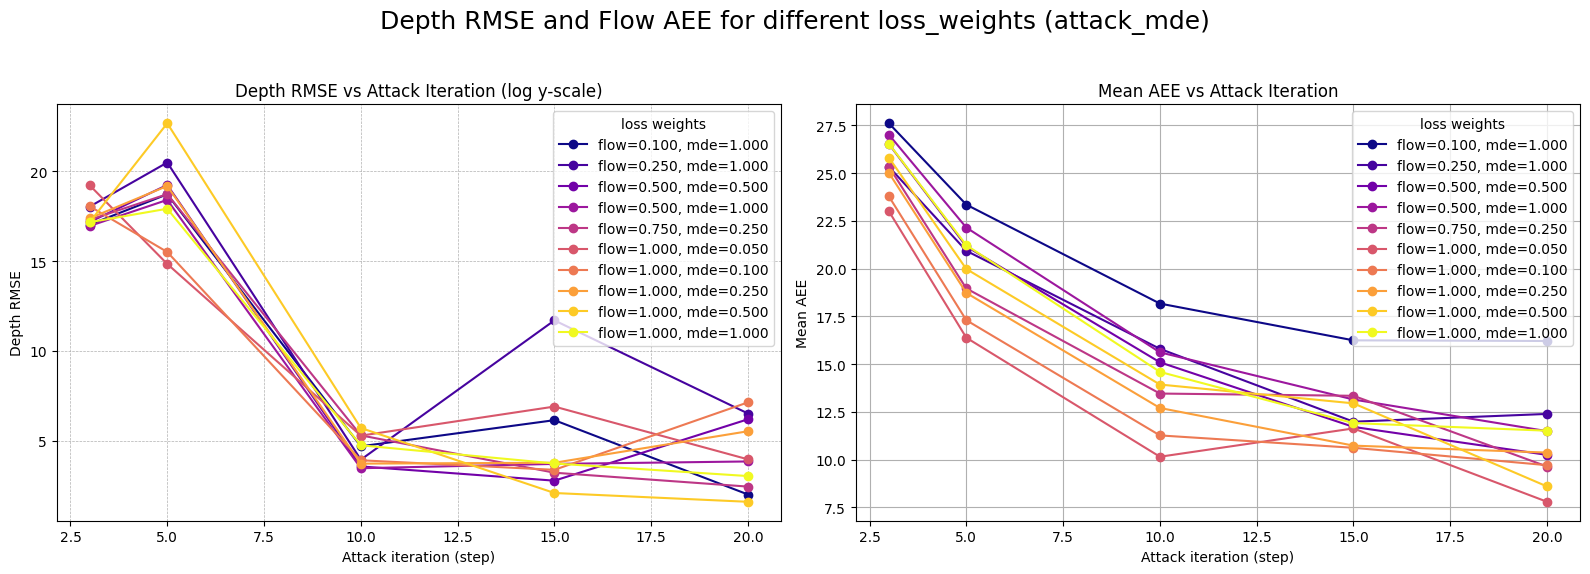

In [9]:
plot_depth_and_flow_by_attack_mde_loss_weights(runs)